# Storm Typing

This notebook provides an automated analysis workflow for storm typing a catalog of storms. The approach used in this notebook stems from Alshehri et al (2024), who developed a nationwide cross-walk dataset between the Global Historic Climate Network of Daily rain gauges (GHNCd) and several extrnal datasets as mentioned below.

https://journals.ametsoc.org/view/journals/hydr/25/12/JHM-D-24-0024.1.xml

The dataset developed by Alshehri et al. (2024) represents daily rain gauge data from the Global Historical Climatology Network daily (GHCNd) network for over 3,000 gauges scattered across the Continental United States (CONUS). The period of record is limited from 1980 to 2018 based on the intersection of the external datasets listed below. Each row in the storm typed GHCNd dataset represents a date and location attributed with an observed rainfall amount and storm type. The attribution of the storm type is based on the hierarchical closest distance within 500-km from a given rain gauge location to the nearest segment of each storm type from a variety of external datasets. 

- Tropical Cyclones (TC): TC tracks at 3-h resolution were obtained from the IBTrACS dataset (Knapp et al. 2010).
- Extratropical Cyclones (ETC): Historical ETC tracks at 6-h resolution were generated by the application of the algorithm of Wang et al. (2013) to the National Centers for Environmental Prediction (NCEP)–National Center for Atmospheric Research (NCAR) reanalysis 1 (Kalnay et al. 1996).
- Fronts: The automated frontal detection algorithm of Biard and Kunkel (2019) was applied to the MERRA-2 reanalysis data to produce a front location dataset at 3-hour resolution.
- Convective Systems (CS): Following TC and ETC for precipitation forcing is a thermodynamic instability, which manifests as convection. CSs can form in two main ways. Some develop on their own due to local atmospheric conditions (internally), while others are triggered by larger weather systems (externally). Based on the methods of Alshehri (2024), when a convective system is triggered by a larger system (i.e., externally driven), it is treated as part of that larger system rather than as a separate storm type. Internally driven convective systems not associated with a large-scale meteorological system were by default encompassed in the ‘Other’ category when neither TC, ETC, nor Fronts were within 500-km of a given rain gauge. For the purposes of storm typing for the Allegheny, storms labeled within the ‘Other' category by Alshehri (2024) are typed as isolated convective systems. 


NOTE: The greatest limitation of this approach is GHCNd rain gauge spatial coverage. Transposition domains with poor spatial coverage will likely not perform well using this methodology and should instead utilize other methods.

# Imports

In [1]:
import os
import json
import pandas as pd
import numpy as np
import pyarrow as pa
import pyarrow.parquet as pq
import datetime
import xarray as xr
import rioxarray  # noqa: F401
import fsspec
import matplotlib.cm as cm
from tqdm import tqdm
import geopandas as gpd
import matplotlib.pyplot as plt
from rasterio.warp import transform_bounds
from rasterio.crs import CRS
from shapely.affinity import affine_transform
import folium
import leafmap.foliumap as leafmap
from branca.element import Element

# File paths and Variables

In [2]:
stations_metadata = "https://www.ncei.noaa.gov/pub/data/ghcn/daily/ghcnd-stations.txt"
ghcnd_metadata_file = (
    "/workspaces/meteorology-tools/inputs/ghcnd/ghcnd_stations.parquet"
)
ghcnd_database_file = "/workspaces/meteorology-tools/inputs/ghcnd/all_stations.parquet"
transposition_file = "/workspaces/meteorology-tools/inputs/transposition_domains/allegheny-transpo-area-v01_valid.json"
huc4_file = "/workspaces/meteorology-tools/inputs/watershed/allegheny_huc.geojson"
ranked_storms_file = (
    "/workspaces/meteorology-tools/inputs/storm_catalog/ranked-storms.csv"
)
storm_catalog_folder = (
    "/workspaces/meteorology-tools/inputs/storm_catalog/allegheny_storms/72hr-events"
)
ibtracs_storms = "/workspaces/meteorology-tools/outputs/03_ibtracs_screening/addtl_tropical_storms.csv"
OUT_DIR = "/workspaces/meteorology-tools/outputs/04_storm_typing"
NUM_STORMS = 450

# Data Prep: GHCNd Rain Gauges

In [3]:
if not os.path.exists(ghcnd_metadata_file):
    stations_df = pd.read_fwf(stations_metadata, header=None)
    stations_df = stations_df.iloc[:, :5]
    stations_df.columns = ["SITE_ID", "LATITUDE", "LONGITUDE", "ELEVATION", "SITE_NAME"]
    stations_df["SITE_ID"] = stations_df["SITE_ID"].astype(str)
    stations_df["LATITUDE"] = stations_df["LATITUDE"].astype(float)
    stations_df["LONGITUDE"] = stations_df["LONGITUDE"].astype(float)
    stations_df["ELEVATION"] = stations_df["ELEVATION"].astype(float)
    stations_df["SITE_NAME"] = stations_df["SITE_NAME"].astype(str)
    stations_df["geometry"] = gpd.points_from_xy(
        stations_df["LONGITUDE"], stations_df["LATITUDE"], crs="EPSG:4326"
    )
    stations_gdf = gpd.GeoDataFrame(stations_df, geometry="geometry")
    stations_gdf.to_parquet(ghcnd_metadata_file, index=False)
else:
    stations_gdf = gpd.read_parquet(ghcnd_metadata_file)

stations_gdf.head()

,SITE_ID,LATITUDE,LONGITUDE,ELEVATION,SITE_NAME,geometry
0,ACW00011604,17.1167,-61.7833,10.1,ST JOHNS COOLIDGE FLD,POINT (-61.7833 17.1167)
1,ACW00011647,17.1333,-61.7833,19.2,ST JOHNS,POINT (-61.7833 17.1333)
2,AE000041196,25.3330,55.5170,34.0,SHARJAH INTER. AIRP,POINT (55.517 25.333)
3,AEM00041194,25.2550,55.3640,10.4,DUBAI INTL,POINT (55.364 25.255)
4,AEM00041217,24.4330,54.6510,26.8,ABU DHABI INTL,POINT (54.651 24.433)


# Data Prep: Precipitation Generating Mechanisms
The generating mechanisms developed by Alshehri et al (2024) for the station precipitation data are available at https://zenodo.org/doi/10.5281/zenodo.10724690.
Download the zip folder 'NSF_CausesData.zip', unzip it and place within /workspaces/meteorology-tools/inputs/ghcnd. The folder contains thousands of csv files representing the thousands of attributed GHCNd stations for precipitation generating mechanisms over the last 30-years and across CONUS. Currently, this represents a NIGHTMARE of a dataset so we first need to repackage this into a more efficient data model.

In [ ]:
def csvs_to_parquet_stream(
    file_list,
    folder_path,
    output_parquet,
    chunksize=25_000,
    csv_kwargs=None,
    verbose=True,
    date_cols=("date", "DATE"),
):
    """
    Stream CSV files into a single Parquet file database without loading all data into memory.

    Args:
        file_list (list[str]): CSV filenames (not full paths).
        folder_path (str): Directory containing the CSVs.
        output_parquet (str): Output Parquet file path.
        chunksize (int|None): Number of rows per chunk to read. Use None to read whole file.
        csv_kwargs (dict|None): Extra kwargs for pandas.read_csv.
        verbose (bool): Print progress.
        date_cols (tuple[str]|list[str]): Column names to parse as datetime.
    """
    csv_kwargs = dict(csv_kwargs or {})
    csv_kwargs.setdefault("na_values", ["NONE"])
    csv_kwargs.setdefault("keep_default_na", True)
    writer = None
    total_rows = 0
    base_schema = None
    base_columns = None
    numeric_cols = None
    try:
        for i, fname in enumerate(file_list, start=1):
            csv_path = os.path.join(folder_path, fname)
            if verbose:
                print(f"[{i}/{len(file_list)}] Reading {csv_path}")
            if chunksize is None:
                chunk_iter = [pd.read_csv(csv_path, **csv_kwargs)]
            else:
                chunk_iter = pd.read_csv(csv_path, chunksize=chunksize, **csv_kwargs)
            for chunk in chunk_iter:
                if hasattr(chunk, "columns"):
                    chunk.columns = chunk.columns.str.strip()
                if base_columns is None:
                    base_columns = list(chunk.columns)
                    table = pa.Table.from_pandas(chunk, preserve_index=False)
                    base_schema = table.schema
                    numeric_cols = [
                        field.name
                        for field in base_schema
                        if pa.types.is_integer(field.type)
                        or pa.types.is_floating(field.type)
                    ]
                    writer = pq.ParquetWriter(output_parquet, base_schema)
                else:
                    chunk = chunk.reindex(columns=base_columns)
                    if numeric_cols:
                        for col in numeric_cols:
                            if col in chunk.columns:
                                chunk[col] = pd.to_numeric(chunk[col], errors="coerce")
                    table = pa.Table.from_pandas(
                        chunk,
                        schema=base_schema,
                        preserve_index=False,
                        safe=False,
                    )
                writer.write_table(table)
                total_rows += len(chunk)
        if verbose:
            print(f"Wrote {total_rows:,} rows to {output_parquet}")
    finally:
        if writer is not None:
            writer.close()

In [5]:
folder_path = "/workspaces/meteorology-tools/inputs/ghcnd/NSF_CausesData/"
file_list = [f for f in os.listdir(folder_path) if f.endswith(".csv")]

if not os.path.exists(ghcnd_database_file):
    csvs_to_parquet_stream(
        file_list,
        folder_path,
        ghcnd_database_file,
        chunksize=25_000,
        date_cols=("date",),
    )
else:
    print(
        f"Parquet database already exists at {ghcnd_database_file}, skipping conversion."
    )

[1/3155] Reading /workspaces/meteorology-tools/inputs/ghcnd/NSF_CausesData/USC00010140.csv
[2/3155] Reading /workspaces/meteorology-tools/inputs/ghcnd/NSF_CausesData/USC00010252.csv
[3/3155] Reading /workspaces/meteorology-tools/inputs/ghcnd/NSF_CausesData/USC00010583.csv
[4/3155] Reading /workspaces/meteorology-tools/inputs/ghcnd/NSF_CausesData/USC00010655.csv
[5/3155] Reading /workspaces/meteorology-tools/inputs/ghcnd/NSF_CausesData/USC00011084.csv
[6/3155] Reading /workspaces/meteorology-tools/inputs/ghcnd/NSF_CausesData/USC00011566.csv
[7/3155] Reading /workspaces/meteorology-tools/inputs/ghcnd/NSF_CausesData/USC00011694.csv
[8/3155] Reading /workspaces/meteorology-tools/inputs/ghcnd/NSF_CausesData/USC00011725.csv
[9/3155] Reading /workspaces/meteorology-tools/inputs/ghcnd/NSF_CausesData/USC00012245.csv
[10/3155] Reading /workspaces/meteorology-tools/inputs/ghcnd/NSF_CausesData/USC00012813.csv
[11/3155] Reading /workspaces/meteorology-tools/inputs/ghcnd/NSF_CausesData/USC00013160.c

All 77+ million rows are now consolidated into a single parquet file (~2GB). The point of this exercise is that now we can query by station IDs that we know (i.e., stations that intersect our domain based on their metadata geometry) to get the data records using SQL filters without having to load the entire dataset into memory.

In [6]:
# GeoDataFrames
stations_gdf = gpd.read_parquet(ghcnd_metadata_file)
transposition_gdf = gpd.read_file(transposition_file)
transposition_gdf = transposition_gdf.to_crs(stations_gdf.crs)
transposition_gdf["layer"] = "Transposition Domain"
transposition_gdf = transposition_gdf[["layer", "geometry"]]
huc4_gdf = gpd.read_file(huc4_file)
huc4_gdf = huc4_gdf.to_crs(stations_gdf.crs)
huc4_gdf["layer"] = "Watershed Boundary"
# DataFrames
ranked_storms_df = pd.read_csv(ranked_storms_file)
ranked_storms_df = ranked_storms_df[
    :NUM_STORMS
]  # e.g., limit to top 450 storms if period of record is 45 years
# find stations within transposition area
merged_stations_gdf = gpd.sjoin(
    stations_gdf, transposition_gdf, how="inner", predicate="intersects"
)
# load master database with only relevant stations to study area
unique_stations = merged_stations_gdf["SITE_ID"].unique().tolist()
master_df = pd.read_parquet(
    ghcnd_database_file, filters=[("station", "in", unique_stations)]
)
# clean up storm type naming conventions
master_df["cause_1"] = master_df["cause_1"].fillna("Convective System")
master_df["cause_1"] = master_df["cause_1"].replace(
    {"FRONT": "Front", "TC": "Tropical Cyclone", "ETC": "Extratropical Cyclone"}
)
master_df

,station,region,state,date,season,precip,qflag,etc_dist,etc_min_slp,etc_avg_slp,...,front_type,ar_dist,ar_ivt,ar_iwv,ar_u850,ar_v850,pw,omega,cause_1,cause_2
0,USC00120177,1,IN,19490101,W,0.0,,1187,985.9,989.8,...,88888,2631,271,26,3.7,2.7,4.0,0.12,Convective System,NaN
1,USC00120177,1,IN,19490102,W,0.0,,1230,986.1,989.8,...,88888,2631,277,23,5.3,0.8,9.9,-0.03,Convective System,NaN
2,USC00120177,1,IN,19490103,W,0.0,,1241,991.8,997.2,...,88888,99999,99999,99999,99999.0,99999.0,20.1,-0.05,Convective System,NaN
3,USC00120177,1,IN,19490104,W,24.4,,883,996.4,1002.3,...,88888,99999,99999,99999,99999.0,99999.0,27.7,-0.11,Convective System,NaN
4,USC00120177,1,IN,19490105,W,12.4,,1057,1003.7,1006.8,...,88888,3633,362,16,9.3,16.2,36.6,-0.25,Convective System,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7325324,USW00094830,1,OH,20181227,W,10.9,,1150,995.9,998.9,...,0,99999,99999,99999,99999.0,99999.0,13.8,-0.18,Front,FRONT
7325325,USW00094830,1,OH,20181228,W,0.0,,451,996.0,997.5,...,1,99999,99999,99999,99999.0,99999.0,26.3,-0.24,Extratropical Cyclone,ETC
7325326,USW00094830,1,OH,20181229,W,0.0,,629,1001.2,1001.2,...,0,99999,99999,99999,99999.0,99999.0,9.3,-0.04,Front,FRONT
7325327,USW00094830,1,OH,20181230,W,0.0,,1913,992.9,995.4,...,0,99999,99999,99999,99999.0,99999.0,9.3,-0.21,Front,FRONT


# GHCNd Stations within the Transposition Domain

In [7]:
# filter merged stations to only those in master database
unique_stations = master_df.station.unique().tolist()
merged_stations_gdf = merged_stations_gdf[
    merged_stations_gdf["SITE_ID"].isin(unique_stations)
]

m = transposition_gdf.explore(color="green", name="Valid Transposition")
huc4_gdf.explore(m=m, color="red", name="Watershed Boundary")
merged_stations_gdf.explore(m=m, color="blue", name="GHCNd Stations")

# Attributing Storm Types

In [8]:
def transpose_watershed_area(
    gdf: gpd.GeoDataFrame, aorc_transform: dict
) -> gpd.GeoDataFrame:
    """
    Transpose a study area using AORC transform parameters.

    Args:
        gdf (GeoDataFrame): GeoDataFrame of the study area to transpose.
        aorc_transform (dict): Dictionary of AORC transform parameters with keys 'a', 'b', 'c', 'd', 'e', 'f'.

    Returns:
        GeoDataFrame: Transposed study area GeoDataFrame.
    """
    transposed_gdf = gdf.copy()
    a = aorc_transform["a"]
    b = aorc_transform["b"]
    c = aorc_transform["c"]
    d = aorc_transform["d"]
    e = aorc_transform["e"]
    f = aorc_transform["f"]
    transform_params = [a, b, d, e, c, f]

    transposed_gdf.geometry = transposed_gdf.geometry.apply(
        lambda geom: affine_transform(geom, transform_params)
    )
    transposed_gdf["layer"] = "Transposed Watershed"
    return transposed_gdf


def classify_cause(causes):
    """
    Classify the cause of a storm based on priority.

    Args:
        causes (pd.Series): Series of cause labels for one group.

    Returns:
        str: The highest priority cause label found in the series, or "Front" if none match.
    """
    # Priority rules in order
    priority = [
        "Tropical Cyclone",
        "Extratropical Cyclone",
        "Convective System",
    ]
    # causes is a Series for one group
    values = set(causes.dropna().values)
    for label in priority:
        if label in values:
            return label
    return "Front"


def determine_storm_type(
    start_date: str, master_df: pd.DataFrame, stations_gdf: gpd.GeoDataFrame
) -> gpd.GeoDataFrame:
    """
    Determine storm type for a given storm date.

    Args:
        start_date (str): Storm start date in 'YYYYMMDD' format.
        master_df (pd.DataFrame): Master DataFrame of GHCNd station data.
        stations_gdf (GeoDataFrame): GeoDataFrame of GHCNd station metadata.

    Returns:
        GeoDataFrame: GeoDataFrame of aggregated GHCNd stations and their classified storm types within the storm period.
    """
    # Setup date range
    start_date = pd.to_datetime(start_date)
    start_date = start_date
    end_date = pd.to_datetime(start_date) + pd.Timedelta(days=3)
    start_date = int(start_date.strftime("%Y%m%d"))
    end_date = int(end_date.strftime("%Y%m%d"))

    # Subset master_df for station and date range
    subset = master_df[
        (master_df["date"] >= start_date) & (master_df["date"] <= end_date)
    ]
    if subset.empty:
        return gpd.GeoDataFrame()
    else:
        subset = (
            subset.groupby("station")["cause_1"]
            .apply(classify_cause)
            .reset_index(name="storm_type")
        )
        subset = pd.merge(subset, stations_gdf, left_on="station", right_on="SITE_ID")[
            ["station", "storm_type", "geometry"]
        ]
        subset = gpd.GeoDataFrame(subset, geometry="geometry", crs=stations_gdf.crs)

        return subset

# Process the Catalog

In [9]:
ranked_storms_df["storm_type"] = pd.Series(
    "Non-Tropical", index=ranked_storms_df.index, dtype="string"
)
ranked_storms_df["storm_lat"] = np.nan
ranked_storms_df["storm_lon"] = np.nan
for row in tqdm(ranked_storms_df.itertuples(), total=len(ranked_storms_df)):
    idx = row.Index
    storm_date = row.storm_date
    storm_rank = row.por_rank
    agg_subset = determine_storm_type(storm_date, master_df, merged_stations_gdf)
    # determine most common storm type
    if agg_subset.empty:
        ranked_storms_df.at[idx, "storm_type"] = "Not Labeled"
    else:
        # transpose the watershed to the storm
        storm_json_file = os.path.join(
            storm_catalog_folder, f"{storm_rank}", f"{storm_rank}.json"
        )
        with open(storm_json_file, "r") as f:
            storm_dict = json.load(f)
        aorc_transform = storm_dict["properties"]["aorc:transform"]
        transposed_watershed = transpose_watershed_area(huc4_gdf, aorc_transform)
        transposed_watershed_center = transposed_watershed.geometry.centroid.iloc[0]
        center_x, center_y = (
            transposed_watershed_center.x,
            transposed_watershed_center.y,
        )
        # determine stations within transposed watershed
        stations_in_watershed = gpd.sjoin(
            agg_subset, transposed_watershed, how="inner", predicate="intersects"
        )
        most_common_type = stations_in_watershed["storm_type"].value_counts().idxmax()
        ranked_storms_df.at[idx, "storm_type"] = most_common_type
        ranked_storms_df.at[idx, "storm_lat"] = center_y
        ranked_storms_df.at[idx, "storm_lon"] = center_x

100%|██████████| 450/450 [01:10<00:00,  6.42it/s]


In [10]:
# counts of storm types
ranked_storms_df.value_counts("storm_type").sort_values(ascending=False)

storm_type
Extratropical Cyclone    217
Front                    140
Not Labeled               56
Tropical Cyclone          22
Convective System         15
Name: count, dtype: int64

In [11]:
# percentage of storms by type
pcts = ranked_storms_df["storm_type"].value_counts(normalize=True) * 100
pcts.round(2).sort_values(ascending=False)

storm_type
Extratropical Cyclone    48.22
Front                    31.11
Not Labeled              12.44
Tropical Cyclone          4.89
Convective System         3.33
Name: proportion, dtype: double[pyarrow]

# Storm Types by Time

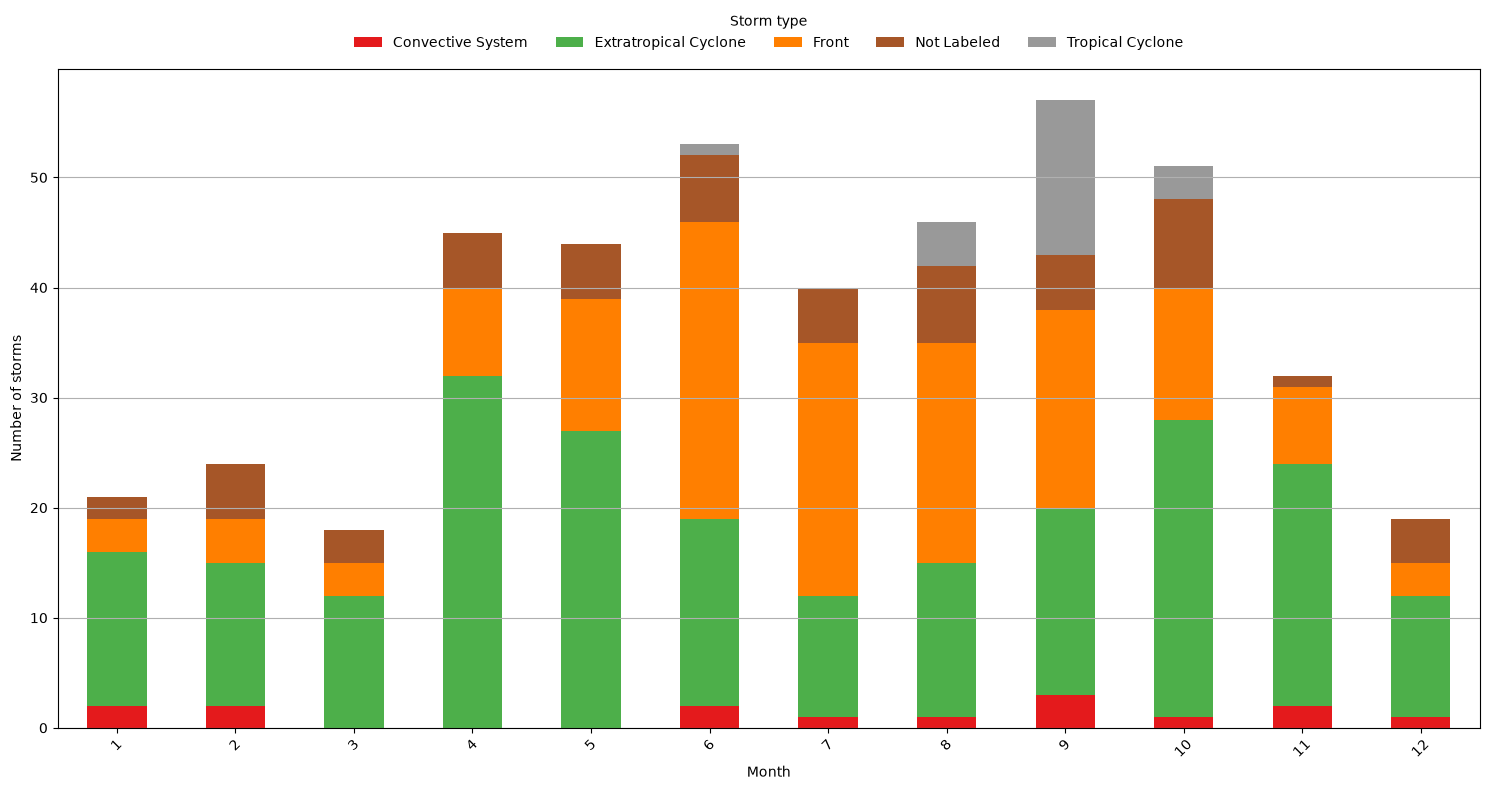

In [12]:
# Count storms by month and type, then pivot to wide format
storm_counts = (
    ranked_storms_df.assign(
        month=pd.to_datetime(ranked_storms_df["storm_date"]).dt.month
    )
    .groupby(["month", "storm_type"])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

ax = storm_counts.plot(kind="bar", stacked=True, colormap="Set1", figsize=(15, 8))
ax.set_xlabel("Month")
ax.set_ylabel("Number of storms")
# add gridlines
ax.grid(axis="y")
# rotate x labels 45 degrees
plt.xticks(rotation=45)

# Horizontal legend below the plot
ax.legend(
    title="Storm type",
    ncol=5,
    loc="lower center",
    bbox_to_anchor=(0.5, 1.02),  # centered, just above the axes
    frameon=False,
    borderaxespad=0.0,
)
plt.tight_layout()
# save figure
plt.savefig(OUT_DIR + "/Storm counts by month and type.png", bbox_inches="tight");

# Storm Types by Space

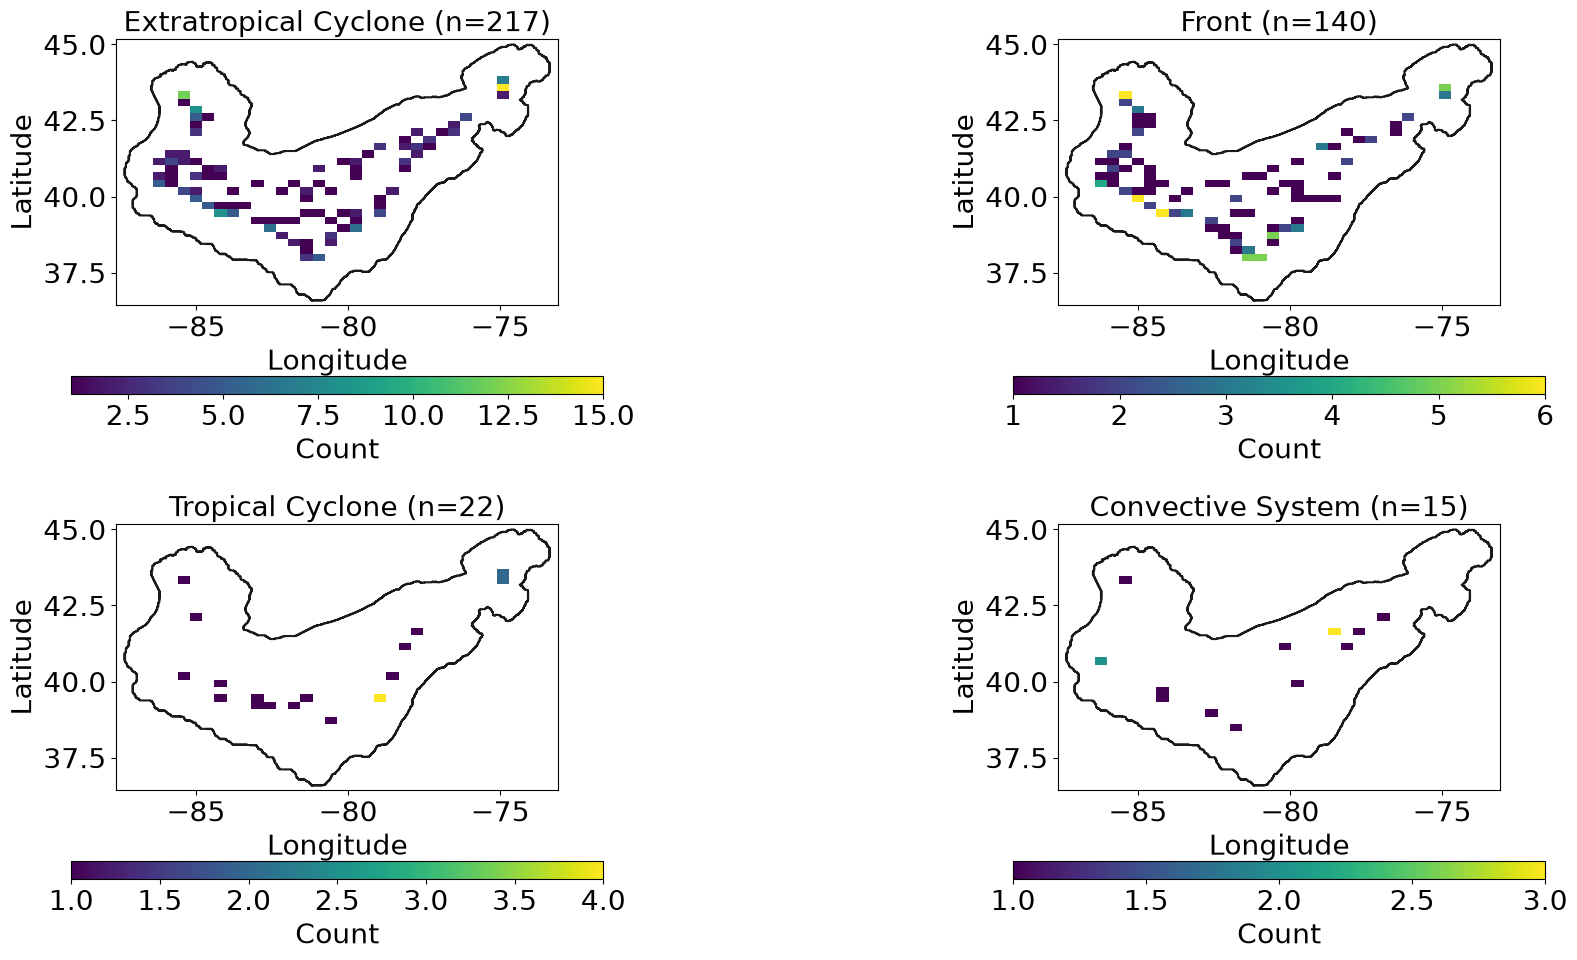

In [13]:
ranked_storms_gdf = gpd.GeoDataFrame(
    ranked_storms_df,
    geometry=gpd.points_from_xy(
        ranked_storms_df["storm_lon"], ranked_storms_df["storm_lat"]
    ),
    crs=stations_gdf.crs,
)
ranked_storms_gdf = ranked_storms_gdf.dropna(subset=["storm_lat", "storm_lon"])

plt.rcParams.update(
    {
        "font.size": 20,
        "axes.titlesize": 20,
        "axes.labelsize": 20,
        "xtick.labelsize": 20,
        "ytick.labelsize": 20,
        "legend.fontsize": 20,
    }
)

plot_df = ranked_storms_gdf.dropna(
    subset=["storm_lat", "storm_lon", "storm_type"]
).copy()
if plot_df.empty:
    raise ValueError(
        "No storms with both coordinates and storm types available for plotting."
    )

storm_types = [
    "Extratropical Cyclone",
    "Front",
    "Tropical Cyclone",
    "Convective System",
]
n_types = len(storm_types)
n_cols = 2
n_rows = int(np.ceil(n_types / n_cols))
bins = 36

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 10))

# boundaries in the same CRS as the points
transpo_proj = transposition_gdf.to_crs(ranked_storms_gdf.crs)
transpo_boundaries = transpo_proj.geometry.boundary

minx, miny, maxx, maxy = transpo_proj.total_bounds
pad = 0.02  # 2% margin
x_pad = (maxx - minx) * pad
y_pad = (maxy - miny) * pad
x_limits = (minx - x_pad, maxx + x_pad)
y_limits = (miny - y_pad, maxy + y_pad)

legend_added = False


def draw_boundary(ax):
    legend_added = False
    for geom in transpo_boundaries:
        if geom.is_empty:
            continue
        segments = geom.geoms if geom.geom_type == "MultiLineString" else [geom]
        for line in segments:
            xs, ys = line.xy
            ax.plot(
                xs,
                ys,
                color="black",
                linewidth=1.5,
                alpha=0.9,
                label="Transposition Boundary" if not legend_added else None,
            )
            legend_added = True


for idx, storm_type in enumerate(storm_types):
    ax = axes[idx // n_cols][idx % n_cols]
    subset = plot_df[plot_df["storm_type"] == storm_type]
    h = ax.hist2d(
        subset["storm_lon"],
        subset["storm_lat"],
        bins=bins,
        cmap="viridis",
        cmin=1,
        range=[[x_limits[0], x_limits[1]], [y_limits[0], y_limits[1]]],
    )
    draw_boundary(ax)
    ax.set_xlim(x_limits)
    ax.set_ylim(y_limits)
    ax.set_aspect("equal", adjustable="box")
    ax.set_title(f"{storm_type} (n={len(subset)})")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    # fig.colorbar(h[3], ax=ax, label="Count")
    cbar = fig.colorbar(
        h[3],
        ax=ax,
        orientation="horizontal",
        pad=0.2,  # space between plot and colorbar
        fraction=0.05,  # shrink the bar height relative to axis
        aspect=30,  # keep it reasonably wide
        label="Count",
    )

# remove unused panels
for j in range(idx + 1, n_rows * n_cols):
    fig.delaxes(axes[j // n_cols][j % n_cols])

if legend_added:
    axes[0][0].legend(loc="upper right")

fig.tight_layout()
# save figure
plt.savefig(
    OUT_DIR + "/2D_Histograms_of_Storm_Type_Locations.png", bbox_inches="tight"
);

# Dynamic Mapping

In [14]:
def _orient_cube_north_up(cube: xr.DataArray) -> xr.DataArray:
    """Ensure the cube is oriented with north up by checking the y-coordinate values."""
    y_dim = None
    for candidate in ("y", "lat", "latitude", "projection_y_coordinate"):
        if candidate in cube.dims:
            y_dim = candidate
            break
    if y_dim is None:
        return cube

    coord = cube.coords.get(y_dim)
    if coord is None or coord.ndim != 1:
        return cube

    values = np.asarray(coord.values)
    if values.size == 0 or not np.isfinite(values).any():
        return cube

    # If latitude is already descending (north to south), no flip needed
    if values[0] > values[-1]:
        return cube

    # If latitude is ascending (south to north), flip to north-to-south for proper image display
    return cube.isel({y_dim: slice(None, None, -1)})


def _extract_crs(da: xr.DataArray):
    """Extract the CRS (Coordinate Reference System) from a DataArray.

    Parameters
    ----------
    da : xr.DataArray
        The input DataArray from which to extract the CRS.
    Returns
    -------
    CRS | None
        The extracted CRS object or None if extraction fails.
    """
    try:
        crs = da.rio.crs  # type: ignore[attr-defined]
        if crs:
            return CRS.from_user_input(crs)
    except Exception:
        pass
    candidate = da.attrs.get("crs") or da.attrs.get("spatial_ref")
    if not candidate and "spatial_ref" in da.coords:
        candidate = da.spatial_ref.attrs.get("spatial_ref")
    if candidate:
        try:
            return CRS.from_user_input(candidate)
        except Exception:
            return None
    return None


def _find_coord_name(da: xr.DataArray, candidates) -> str | None:
    for name in candidates:
        if name in da.coords:
            return name
    return None


def _compute_overlay_bounds(da: xr.DataArray):
    """Compute the bounding box for the storm overlay based on the coordinates of the DataArray.

    Parameters
    ----------
    da : xr.DataArray
        The input DataArray for which to compute the overlay bounds.
    Returns
    -------
    list | None
        The bounding box [[south, west], [north, east]] or None if computation fails.
    """
    x_coord = _find_coord_name(da, ("lon", "longitude", "x"))
    y_coord = _find_coord_name(da, ("lat", "latitude", "y"))
    if x_coord is None or y_coord is None:
        return None
    x_vals = np.asarray(da[x_coord].values)
    y_vals = np.asarray(da[y_coord].values)
    if x_vals.size == 0 or y_vals.size == 0:
        return None
    if np.isnan(x_vals).all() or np.isnan(y_vals).all():
        return None
    min_x, max_x = float(np.nanmin(x_vals)), float(np.nanmax(x_vals))
    min_y, max_y = float(np.nanmin(y_vals)), float(np.nanmax(y_vals))
    source_bounds = (min_x, min_y, max_x, max_y)
    crs = _extract_crs(da)
    if crs is None or crs.to_epsg() == 4326:
        return [[min_y, min_x], [max_y, max_x]]
    try:
        west, south, east, north = transform_bounds(
            crs,
            "EPSG:4326",
            *source_bounds,
            densify_pts=21,
        )
    except Exception as exc:
        print(f"Failed to transform storm bounds to WGS84: {exc}")
        return None
    return [[south, west], [north, east]]


def _downsample_for_overlay(
    da: xr.DataArray,
    max_size: int = 1200,
) -> xr.DataArray:
    """Downsample large rasters for map overlays to limit memory usage."""
    if da is None:
        return da

    dim_pairs = [
        ("y", "x"),
        ("lat", "lon"),
        ("latitude", "longitude"),
        ("projection_y_coordinate", "projection_x_coordinate"),
    ]
    y_dim = x_dim = None
    for cand_y, cand_x in dim_pairs:
        if cand_y in da.dims and cand_x in da.dims:
            y_dim, x_dim = cand_y, cand_x
            break
    if y_dim is None or x_dim is None:
        if len(da.dims) >= 2:
            y_dim, x_dim = da.dims[-2], da.dims[-1]
        else:
            return da

    size_y = int(da.sizes.get(y_dim, 0))
    size_x = int(da.sizes.get(x_dim, 0))
    if size_y == 0 or size_x == 0:
        return da

    scale = max(size_y, size_x) / max_size
    if scale <= 1:
        return da

    step = int(np.ceil(scale))
    return da.isel({y_dim: slice(None, None, step), x_dim: slice(None, None, step)})


def _prepare_rgba_image(
    image_data: np.ndarray, cmap_name: str = "Spectral_r"
) -> np.ndarray | None:
    """Convert precipitation totals into an RGBA image for folium overlays.

    Parameters
    ----------
    image_data : np.ndarray
        The input image data array.
    cmap_name : str, optional
        The name of the matplotlib colormap to use. Default is "Spectral_r".

    Returns
    -------
    np.ndarray | None
        The RGBA image array or None if input is empty or invalid.
    """
    if image_data.size == 0:
        return None
    finite_mask = np.isfinite(image_data)
    if not finite_mask.any():
        return None
    valid_data = image_data[finite_mask]
    min_val = float(valid_data.min())
    max_val = float(valid_data.max())
    if np.isclose(max_val, min_val):
        normalized = np.zeros_like(image_data, dtype=float)
    else:
        normalized = (image_data - min_val) / (max_val - min_val)
    normalized = np.clip(np.nan_to_num(normalized, nan=0.0), 0.0, 1.0)
    cmap = plt.get_cmap(cmap_name)
    rgba = (cmap(normalized) * 255).astype(np.uint8)
    rgba[..., 3] = np.where(finite_mask, rgba[..., 3], 0)
    return rgba


def add_storm_layer(m, storm_data) -> None:
    """Add storm overlay to the map from IceChunk dataset

    Parameters
    ----------
        m (leafmap.Map): The leafmap map object to add the overlay to.
        storm_data (xr.DataArray): The storm data to overlay.
    Returns
    -------
        None
    """

    bounds = _compute_overlay_bounds(storm_data)
    storm_overlay = _downsample_for_overlay(storm_data)
    rgba_image = _prepare_rgba_image(
        storm_overlay.values.astype(np.float32, copy=False)
    )
    if rgba_image is None:
        return

    folium.raster_layers.ImageOverlay(
        image=rgba_image,
        bounds=bounds,
        opacity=0.75,
        name="72-hour Accumulated Precipitation",
        interactive=False,
        cross_origin=False,
        zindex=1000,
    ).add_to(m)


def style_models(feature):
    return {"fillColor": "#1e90ff"}


def map_storm_typing(
    huc4_gdf: gpd.GeoDataFrame,
    transposed_watershed: gpd.GeoDataFrame,
    transposition_gdf: gpd.GeoDataFrame,
    storm_type_pts_gdf: gpd.GeoDataFrame,
    ds_aorc_storm: xr.Dataset,
) -> leafmap.Map:
    """Create a folium map visualizing storm typing results.

    Args:
        huc4_gdf (GeoDataFrame): GeoDataFrame of the watershed boundary.
        transposed_watershed (GeoDataFrame): GeoDataFrame of the transposed watershed boundary.
        transposition_gdf (GeoDataFrame): GeoDataFrame of the transposition domain boundary.
        storm_type_pts_gdf (GeoDataFrame): GeoDataFrame of the storm-typed points.
        ds_aorc_storm (xr.Dataset): AORC dataset for the storm period.
    Returns:
        leafmap.Map: Leafmap map object with the visualizations.
    """
    # Build map centered on the points
    c_lat, c_lon = (
        storm_type_pts_gdf.geometry.y.mean(),
        storm_type_pts_gdf.geometry.x.mean(),
    )
    m = leafmap.Map(
        locate_control=False,
        atlon_control=False,
        draw_export=False,
        draw_control=False,
        minimap_control=False,
        toolbar_control=False,
        layers_control=True,
    )
    # Storm Layer (raster)
    add_storm_layer(m, ds_aorc_storm)
    m.add_colorbar(
        colors=["blue", "cyan", "green", "yellow", "orange", "red"],
        caption="72-Hour Accumulated Precipitation (inches)",
        vmax=ds_aorc_storm.max().values,
        vmin=ds_aorc_storm.min().values,
    )

    # Boundary Layers
    m.add_gdf(
        transposition_gdf,
        layer_name="Transposition Domain",
        info_mode="on_hover",
        fields=["layer"],
        style_function=lambda feature: {"fillColor": "#ff381e", "color": "#ff1e1e"},
        zoom_on_click=True,
        show=True,
    )
    m.add_gdf(
        huc4_gdf,
        layer_name="Watershed Boundary",
        info_mode="on_hover",
        fields=["layer"],
        style_function=style_models,
        zoom_on_click=False,
        show=True,
    )
    m.add_gdf(
        transposed_watershed,
        layer_name="Transposed Watershed",
        info_mode="on_hover",
        fields=["layer"],
        style_function=lambda feature: {
            "fillColor": "#32cd32",
            "color": "#32cd32",
        },
        zoom_on_click=False,
        show=True,
    )

    # Points Layer (categorical)
    category_col = "storm_type"
    if category_col not in storm_type_pts_gdf.columns:
        non_geom = [c for c in storm_type_pts_gdf.columns if c != "geometry"]
        if not non_geom:
            raise ValueError(
                "storm_type_pts_gdf must have a non-geometry column for categories"
            )
        category_col = non_geom[0]

    palette = [
        "#1f78b4",
        "#33a02c",
        "#eb0d0d",
        "#6a3d9a",
        "#ff7f00",
        "#b15928",
        "#a6cee3",
        "#b2df8a",
    ]
    categories = sorted(storm_type_pts_gdf[category_col].dropna().unique())
    color_map = {cat: palette[i % len(palette)] for i, cat in enumerate(categories)}

    for _, row in storm_type_pts_gdf.iterrows():
        geom = row.geometry
        if geom is None:
            continue
        folium.CircleMarker(
            location=[geom.y, geom.x],
            radius=4,
            color=color_map.get(row[category_col], "#555555"),
            fill=True,
            fill_color=color_map.get(row[category_col], "#555555"),
            fill_opacity=0.9,
            weight=1,
            popup=f"{category_col}: {row[category_col]}",
        ).add_to(m)

    # Legend (boundaries + points)
    legend_items = [
        ("line", "#1f78b4", "Transposition Domain"),
        ("line", "#080808", "Watershed Boundary"),
        ("dash", "#080808", "Transposed Watershed"),
    ]
    legend_items += [("point", color_map[cat], f"{cat}") for cat in categories]

    legend_rows = []
    for kind, color, label in legend_items:
        if kind == "line":
            symbol = f"<span style='display:inline-block;width:16px;border-top:3px solid {color};margin-right:6px;'></span>"
        elif kind == "dash":
            symbol = f"<span style='display:inline-block;width:16px;border-top:3px dashed {color};margin-right:6px;'></span>"
        else:
            symbol = f"<span style='display:inline-block;width:10px;height:10px;border-radius:50%;background:{color};margin-right:6px;border:1px solid #444;'></span>"
        legend_rows.append(f"<div style='margin-bottom:4px;'>{symbol}{label}</div>")

    legend_html = """
    <div style="
        position: fixed;
        bottom: 30px; left: 30px; z-index: 9999;
        background: white; padding: 10px 12px; border: 1px solid #888;
        box-shadow: 0 2px 6px rgba(0,0,0,0.15); font-size: 12px;
    ">
    <div style="font-weight: 600; margin-bottom: 6px;">Legend</div>
    {rows}
    </div>
    """.format(rows="".join(legend_rows))
    m.get_root().html.add_child(Element(legend_html))

    m.clear_controls()
    m.set_center(c_lon, c_lat, zoom=6)

    return m


def get_aorc(
    start_dt: datetime.datetime,
    end_dt: datetime.datetime,
    transposition_gdf: gpd.GeoDataFrame,
) -> xr.Dataset:
    """Get AORC data from S3 for given time range and clip to transposition geometry.

    Args:
        start_dt (datetime.datetime): Start datetime (inclusive).
        end_dt (datetime.datetime): End datetime (exclusive).
        transposition_gdf (gpd.GeoDataFrame): GeoDataFrame containing transposition geometry.
    Returns:
        xr.Dataset: Clipped AORC dataset.
    """
    # format to datetime
    storm_start_dt = datetime.datetime.fromisoformat(start_dt)
    storm_end_dt = datetime.datetime.fromisoformat(end_dt)
    storm_year = storm_start_dt.year
    # construct url
    base_url = "s3://noaa-nws-aorc-v1-1-1km"
    single_year_url = f"{base_url}/{storm_year}.zarr/"
    # open zarr dataset
    ds = xr.open_zarr(fsspec.get_mapper(single_year_url, anon=True), consolidated=True)
    ds = ds["APCP_surface"]

    transposition_geom_for_clip = list(transposition_gdf.geometry)
    bounds = transposition_gdf.bounds

    print(f"Subsetting AORC data from {storm_start_dt} to {storm_end_dt}")
    subsection = ds.sel(
        time=slice(storm_start_dt, storm_end_dt),
        longitude=slice(bounds.minx[0], bounds.maxx[0]),
        latitude=slice(bounds.miny[0], bounds.maxy[0]),
    )

    # Clip to geometry
    if not hasattr(subsection, "rio"):
        raise ImportError(
            "Missing rioxarray accessor. Install/import rioxarray before calling get_aorc()."
        )
    clipped = subsection.rio.clip(
        transposition_geom_for_clip, drop=True, all_touched=True
    )

    # Sum over time dimension to get total precipitation
    total_precipitation = clipped.sum(dim="time")
    # Convert from mm to inches
    total_precipitation = (total_precipitation / 1000) * 39.3701
    # Mask values of 0 to NaN
    total_precipitation = total_precipitation.where(total_precipitation > 0)
    # Ensure north-up orientation
    total_precipitation = _orient_cube_north_up(total_precipitation)
    return total_precipitation


def check_storm_type(
    start_date: str,
    storm_rank: int,
    master_df: pd.DataFrame,
    stations_gdf: gpd.GeoDataFrame,
    huc4_gdf: gpd.GeoDataFrame,
    transposition_gdf: gpd.GeoDataFrame,
    storm_catalog_folder: str,
) -> folium.Map:
    """
    Check storm type for a given storm date and create a map visualization.

    Args:
        start_date (str): Storm start date in 'YYYYMMDD' format.
        storm_rank (int): Storm rank identifier.
        master_df (pd.DataFrame): Master DataFrame of GHCNd station data.
        stations_gdf (gpd.GeoDataFrame): GeoDataFrame of GHCNd station metadata.
        huc4_gdf (GeoDataFrame): GeoDataFrame of watershed boundary.
        transposition_gdf (GeoDataFrame):
        storm_catalog_folder (str): Path to the storm catalog folder.

    Returns:
        folium.Map: Folium map object visualizing the storm typing.
    """
    # Determine storm types at stations during storm period
    storm_output = determine_storm_type(start_date, master_df, stations_gdf)
    # Transpose the watershed to the storm
    storm_json_file = os.path.join(
        storm_catalog_folder, f"{storm_rank}", f"{storm_rank}.json"
    )
    with open(storm_json_file, "r") as f:
        storm_dict = json.load(f)
    aorc_transform = storm_dict["properties"]["aorc:transform"]
    transposed_watershed = transpose_watershed_area(huc4_gdf, aorc_transform)
    # Determine stations within transposed watershed
    stations_in_watershed = gpd.sjoin(
        storm_output, transposed_watershed, how="inner", predicate="intersects"
    )
    storm_type = stations_in_watershed["storm_type"].value_counts().idxmax()
    print(f"There are {len(storm_output)} stations reporting during the storm period.")
    print(
        f"The most common storm type registered within the transposed watershed domain is {storm_type}."
    )

    # Prep args for AORC data retrieval
    storm_start = pd.to_datetime(start_date)
    storm_end = storm_start + pd.Timedelta(days=3)
    storm_start = storm_start.isoformat()
    storm_end = storm_end.isoformat()
    # Get AORC data for storm period
    ds_aorc_storm = get_aorc(
        start_dt=storm_start,
        end_dt=storm_end,
        transposition_gdf=transposition_gdf,
    )
    storm_map = map_storm_typing(
        huc4_gdf, transposed_watershed, transposition_gdf, storm_output, ds_aorc_storm
    )
    return storm_map

# Tropical vs. Non-Tropical
Per the SOP, the default classification of storm types is Tropical and Non-Tropical. Special cases may exist when more storm types are warranted, but the default for any study always begins with this binary classification approach.

In [15]:
# set all storm types that are not "Tropical Cyclone" or "Not Labeled" to "Non-Tropical"
ranked_storms_df.loc[
    ~ranked_storms_df["storm_type"].isin(["Tropical Cyclone", "Not Labeled"]),
    "storm_type",
] = "Non-Tropical"
# percentage of storms by type
counts = ranked_storms_df["storm_type"].value_counts()
print("Storm Type Counts:\n", counts)
pcts = ranked_storms_df["storm_type"].value_counts(normalize=True) * 100
pcts = pcts.round(2).sort_values(ascending=False)
print("\nStorm Type Percentages:\n", pcts)
num_tropical = counts.get("Tropical Cyclone", 0)

Storm Type Counts:
 storm_type
Non-Tropical        372
Not Labeled          56
Tropical Cyclone     22
Name: count, dtype: int64[pyarrow]

Storm Type Percentages:
 storm_type
Non-Tropical        82.67
Not Labeled         12.44
Tropical Cyclone     4.89
Name: proportion, dtype: double[pyarrow]


# Visual Spot Check
Visually inspect and verify the assignment of storm types

In [16]:
ranked_storms_df[ranked_storms_df.storm_type == "Tropical Cyclone"].head(num_tropical)

,storm_date,mean,min,max,por_rank,annual_rank,storm_type,storm_lat,storm_lon
1,2008-09-12T00,6.11,1.11,9.79,2,1,Tropical Cyclone,42.025968,-85.120508
6,2004-09-16T00,4.68,1.47,8.36,7,1,Tropical Cyclone,39.459404,-81.253996
7,2004-09-07T00,4.45,1.85,9.04,8,2,Tropical Cyclone,39.259412,-81.753976
9,2012-10-29T00,4.30,2.09,10.45,10,1,Tropical Cyclone,40.126044,-78.587436
16,1999-09-15T00,3.96,1.47,8.64,17,1,Tropical Cyclone,43.659236,-74.720924
18,1996-09-04T00,3.91,0.37,13.33,19,1,Tropical Cyclone,39.426072,-79.020752
25,2011-08-28T00,3.78,0.52,14.28,26,2,Tropical Cyclone,43.659236,-74.720924
54,1995-10-03T00,3.35,1.77,4.68,55,2,Tropical Cyclone,39.926052,-84.020552
57,1985-09-27T00,3.31,1.28,6.64,58,2,Tropical Cyclone,43.459244,-75.020912
65,2003-09-18T00,3.20,0.51,9.61,66,4,Tropical Cyclone,39.392740,-79.054084


In [17]:
selected_storm_idx = (
    400  # Change this index to select a different storm from the table above
)
test_storm = ranked_storms_df.iloc[selected_storm_idx]
test_storm

storm_date        2005-09-24T00
mean                        2.1
min                        0.71
max                        4.97
por_rank                    401
annual_rank                   8
storm_type     Tropical Cyclone
storm_lat             40.192708
storm_lon            -85.553824
Name: 400, dtype: object

There are 283 stations reporting during the storm period.
The most common storm type registered within the transposed watershed domain is Tropical Cyclone.
Subsetting AORC data from 2005-09-24 00:00:00 to 2005-09-27 00:00:00



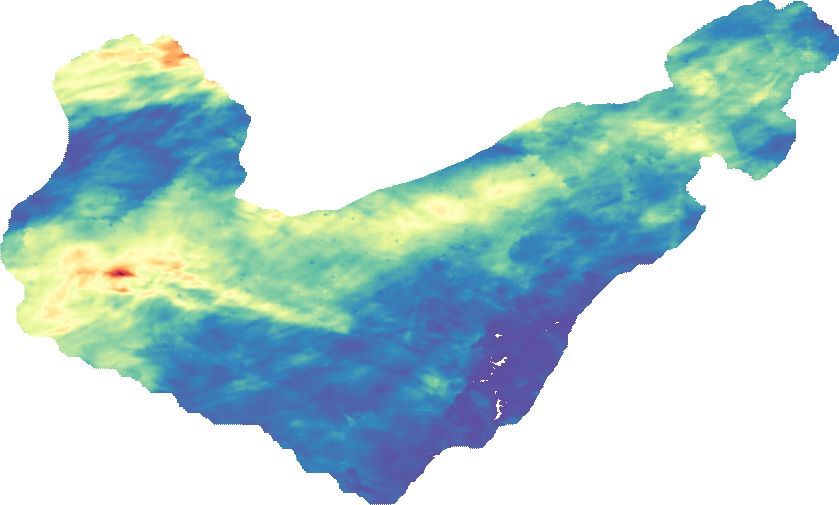

In [18]:
storm_map = check_storm_type(
    start_date=test_storm.storm_date,
    storm_rank=test_storm.por_rank,
    master_df=master_df,
    stations_gdf=merged_stations_gdf,
    huc4_gdf=huc4_gdf,
    transposition_gdf=transposition_gdf,
    storm_catalog_folder=storm_catalog_folder,
)
storm_map

# Back-Filling with IBTrACs
Storms that were not labeled represent more recent storms that fall outside of the date range (1980 - 2018) from the provided dataset produced by Alshehri et al (2024). Therefore, a back-filling method based on solely the IBTrACS dataset is now required for the more recent years of observation.

In [19]:
ibtracs_storms_df = pd.read_csv(ibtracs_storms)
unlabeled_storms = ranked_storms_df[ranked_storms_df.storm_type == "Not Labeled"]

Merge the unlabeled storms with the IBTrACS storms dataset to find potential matches. The intersection of the two datasets based on storm_date represents storms that were not labeled in the ranked_storms_df but are present in the IBTrACS dataset as potential matches. This merge operation will help identify any additional storms that may have been missed in the initial classification.

In [20]:
merged_df = pd.merge(
    unlabeled_storms,
    ibtracs_storms_df,
    left_on="storm_date",
    right_on="storm_date",
    how="left",
    suffixes=("_ranked", "_ibtracs"),
)
merged_df = merged_df.dropna(subset=["storm_rank"], inplace=False)
num_additional_matches = len(merged_df)
print(
    f"Found {num_additional_matches} additional matches in IBTrACS for previously unlabeled storms."
)
merged_df

Found 8 additional matches in IBTrACS for previously unlabeled storms.


,storm_date,mean,min,max,por_rank,annual_rank,storm_type,storm_lat,storm_lon,storm_rank,lat,lon
2,2021-08-30T00,3.63,0.98,6.84,33,2,Not Labeled,NaN,NaN,33.0,[16.5 17. 17.39999962 17.799999...,[-78.90000153 -79.19999695 -79.5 -79.80...
4,2024-08-07T00,3.52,0.25,10.03,39,2,Not Labeled,NaN,NaN,39.0,[20.39999962 20.5 20.60000038 20.700000...,[-75.80000305 -76.69999695 -77.5 -78.19...
5,2021-08-17T00,3.45,1.02,7.37,47,3,Not Labeled,NaN,NaN,47.0,[13.89999962 14.30000019 14.60000038 14.899999...,[-58.70000076 -59.40000153 -60.09999847 -60.79...
7,2024-09-25T00,3.26,0.49,11.08,62,3,Not Labeled,NaN,NaN,62.0,[17.20000076 17.5 17.79999924 18. ...,[-81.69999695 -81.80000305 -81.90000153 -82. ...
10,2024-07-09T00,3.00,0.67,6.94,88,4,Not Labeled,NaN,NaN,88.0,[ 8.89999962 8.89999962 9. 9.100000...,[-39.59999847 -40.40000153 -41.29999924 -42.20...
30,2020-08-27T00,2.47,0.62,4.92,206,3,Not Labeled,NaN,NaN,206.0,[14.39999962 14.89999962 15.39999962 15.800000...,[-47.29999924 -48.5 -49.59999847 -50.59...
38,2020-10-28T00,2.24,1.35,3.36,314,6,Not Labeled,NaN,NaN,314.0,[18.39999962 18.29999924 18.20000076 18.100000...,[-82.59999847 -82.80000305 -83. -83.09...
40,2020-08-02T00,2.18,0.70,4.12,342,7,Not Labeled,NaN,NaN,342.0,[12.5 12.80000019 13.19999981 13.600000...,[-54. -55.29999924 -56.40000153 -57.40...


In [21]:
from shapely.geometry import LineString
import ast
import re


def _parse_ibtracs_coord_list(value):
    """Parse IBTrACS lon/lat values stored as arrays, JSON strings, or numpy-style strings."""
    if isinstance(value, (list, tuple, np.ndarray, pd.Series)):
        raw = list(value)
        numeric = pd.to_numeric(pd.Series(raw), errors="coerce")
        return numeric.replace([np.inf, -np.inf], np.nan).dropna().tolist()

    if pd.isna(value):
        return []

    if isinstance(value, str):
        text = value.strip()
        if not text:
            return []
        try:
            raw = json.loads(text)
        except Exception:
            try:
                raw = ast.literal_eval(text)
            except Exception:
                tokens = re.findall(r"[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?", text)
                if not tokens:
                    return []
                numeric = pd.to_numeric(pd.Series(tokens), errors="coerce")
                return numeric.replace([np.inf, -np.inf], np.nan).dropna().tolist()
        if not isinstance(raw, (list, tuple, np.ndarray, pd.Series)):
            raw = [raw]
        numeric = pd.to_numeric(pd.Series(raw), errors="coerce")
        return numeric.replace([np.inf, -np.inf], np.nan).dropna().tolist()

    numeric = pd.to_numeric(pd.Series([value]), errors="coerce")
    return numeric.replace([np.inf, -np.inf], np.nan).dropna().tolist()


def check_ibtracs_track(
    storm_date: str,
    storm_rank: int,
    lat_values,
    lon_values,
    huc4_gdf: gpd.GeoDataFrame,
    transposition_gdf: gpd.GeoDataFrame,
    storm_catalog_folder: str,
) -> leafmap.Map:
    """Create a single-storm IBTrACS map with boundaries and 72-hour precipitation."""
    lon_vals = _parse_ibtracs_coord_list(lon_values)
    lat_vals = _parse_ibtracs_coord_list(lat_values)
    n = min(len(lon_vals), len(lat_vals))
    if n < 2:
        raise ValueError(
            "IBTrACS storm track must contain at least two valid lon/lat points."
        )

    storm_xy = pd.DataFrame(
        {
            "lon": lon_vals[:n],
            "lat": lat_vals[:n],
        }
    ).dropna(subset=["lon", "lat"])
    if len(storm_xy) < 2:
        raise ValueError(
            "IBTrACS storm track has fewer than two valid coordinate pairs after cleaning."
        )

    storm_line = LineString(zip(storm_xy["lon"], storm_xy["lat"]))
    storm_line_gdf = gpd.GeoDataFrame(
        {
            "storm_date": [storm_date],
            "storm_rank": [storm_rank],
            "layer": ["IBTrACS Track"],
        },
        geometry=[storm_line],
        crs="EPSG:4326",
    ).to_crs(huc4_gdf.crs)

    storm_json_file = os.path.join(
        storm_catalog_folder, f"{storm_rank}", f"{storm_rank}.json"
    )
    with open(storm_json_file, "r") as f:
        storm_dict = json.load(f)
    aorc_transform = storm_dict["properties"]["aorc:transform"]
    transposed_watershed = transpose_watershed_area(huc4_gdf, aorc_transform)

    storm_start = pd.to_datetime(storm_date)
    storm_end = storm_start + pd.Timedelta(days=3)
    ds_aorc_storm = get_aorc(
        start_dt=storm_start.isoformat(),
        end_dt=storm_end.isoformat(),
        transposition_gdf=transposition_gdf,
    )

    m = leafmap.Map(
        locate_control=False,
        atlon_control=False,
        draw_export=False,
        draw_control=False,
        minimap_control=False,
        toolbar_control=False,
        layers_control=True,
    )

    add_storm_layer(m, ds_aorc_storm)
    m.add_colorbar(
        colors=["blue", "cyan", "green", "yellow", "orange", "red"],
        caption="72-Hour Accumulated Precipitation (inches)",
        vmax=ds_aorc_storm.max().values,
        vmin=ds_aorc_storm.min().values,
    )

    m.add_gdf(
        transposition_gdf,
        layer_name="Transposition Domain",
        info_mode="on_hover",
        fields=["layer"],
        style_function=lambda feature: {"fillColor": "#ff381e", "color": "#ff1e1e"},
        zoom_on_click=True,
        show=True,
    )
    m.add_gdf(
        huc4_gdf,
        layer_name="Watershed Boundary",
        info_mode="on_hover",
        fields=["layer"],
        style_function=style_models,
        zoom_on_click=False,
        show=True,
    )
    m.add_gdf(
        transposed_watershed,
        layer_name="Transposed Watershed",
        info_mode="on_hover",
        fields=["layer"],
        style_function=lambda feature: {"fillColor": "#32cd32", "color": "#32cd32"},
        zoom_on_click=False,
        show=True,
    )
    m.add_gdf(
        storm_line_gdf,
        layer_name="IBTrACS Track",
        info_mode="on_hover",
        fields=["storm_date", "storm_rank"],
        style_function=lambda feature: {
            "color": "#0f0f0f",
            "weight": 4,
            "opacity": 0.95,
        },
        zoom_on_click=False,
        show=True,
    )

    line_center_4326 = storm_line_gdf.to_crs("EPSG:4326").geometry.centroid.iloc[0]
    m.set_center(line_center_4326.x, line_center_4326.y, zoom=6)
    return m

Subsetting AORC data from 2020-08-02 00:00:00 to 2020-08-05 00:00:00



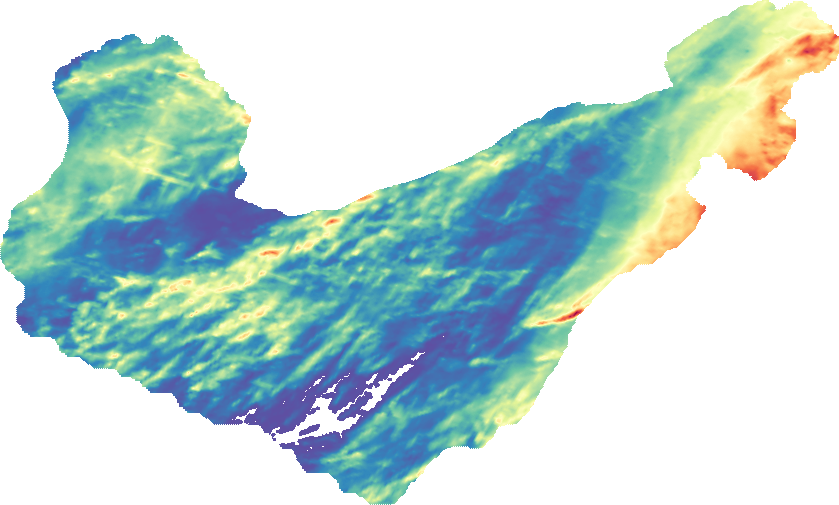

In [22]:
selected_storm_idx = 7  # Change this index to select a different merged storm
ibtracs_map = None
if not merged_df.empty:
    row = merged_df.iloc[selected_storm_idx]
    ibtracs_map = check_ibtracs_track(
        storm_date=row["storm_date"],
        storm_rank=int(row["storm_rank"]),
        lat_values=row["lat"],
        lon_values=row["lon"],
        huc4_gdf=huc4_gdf,
        transposition_gdf=transposition_gdf,
        storm_catalog_folder=storm_catalog_folder,
    )
else:
    print("No merged storm rows available to map.")
ibtracs_map

# Manually Assigned Indexes
Rerun the above cell for each unlabeled storm that was identified by the IBTrACS dataset as a potential candidate. Afterwards populate the list below with the indexes for storms that were not deemed to be tropical events based on your visual inspection.

In [23]:
invalid_storm_idxs = [3, 5]
valid_storm_idxs = [i for i in range(len(merged_df)) if i not in invalid_storm_idxs]
print(f"Valid storm indices for mapping: {valid_storm_idxs}")
print(f"Invalid storm indices for mapping: {invalid_storm_idxs}")

Valid storm indices for mapping: [0, 1, 2, 4, 6, 7]
Invalid storm indices for mapping: [3, 5]


Now we can begin to backfill the dataset of unlabeled storms and merge it back into the master dataset as a final product

In [24]:
backfilled_storms = (
    merged_df.copy()
    .reset_index(drop=True)
    .drop(columns=["lat", "lon", "storm_lat", "storm_lon"])
)
backfilled_storms.loc[invalid_storm_idxs, "storm_type"] = "Not Labeled"
backfilled_storms.loc[valid_storm_idxs, "storm_type"] = "Tropical Cyclone"
backfilled_storms

,storm_date,mean,min,max,por_rank,annual_rank,storm_type,storm_rank
0,2021-08-30T00,3.63,0.98,6.84,33,2,Tropical Cyclone,33.0
1,2024-08-07T00,3.52,0.25,10.03,39,2,Tropical Cyclone,39.0
2,2021-08-17T00,3.45,1.02,7.37,47,3,Tropical Cyclone,47.0
3,2024-09-25T00,3.26,0.49,11.08,62,3,Not Labeled,62.0
4,2024-07-09T00,3.00,0.67,6.94,88,4,Tropical Cyclone,88.0
5,2020-08-27T00,2.47,0.62,4.92,206,3,Not Labeled,206.0
6,2020-10-28T00,2.24,1.35,3.36,314,6,Tropical Cyclone,314.0
7,2020-08-02T00,2.18,0.70,4.12,342,7,Tropical Cyclone,342.0


In [25]:
# replace the storm types in the original ranked_storms_df with the backfilled values from merged_df
final_storm_types_df = ranked_storms_df.copy()
for idx, row in backfilled_storms.iterrows():
    storm_date = row["storm_date"]
    storm_rank = row["storm_rank"]
    storm_type = row["storm_type"]
    final_storm_types_df.loc[
        (final_storm_types_df["storm_date"] == storm_date)
        & (final_storm_types_df["por_rank"] == storm_rank),
        "storm_type",
    ] = storm_type
# replace the remaining "Not Labeled" storm types with "Non-Tropical"
final_storm_types_df.loc[
    final_storm_types_df["storm_type"] == "Not Labeled", "storm_type"
] = "Non-Tropical"
# counts of storm types
storm_counts = final_storm_types_df.value_counts("storm_type").sort_values(
    ascending=False
)
print("Storm Type Counts:\n", storm_counts)
print(f"Number of Storms: {len(final_storm_types_df)}")
final_storm_types_df = final_storm_types_df[
    ["storm_date", "por_rank", "annual_rank", "storm_type", "mean", "min", "max"]
]
final_storm_types_df

Storm Type Counts:
 storm_type
Non-Tropical        422
Tropical Cyclone     28
Name: count, dtype: int64
Number of Storms: 450


,storm_date,por_rank,annual_rank,storm_type,mean,min,max
0,2011-09-06T00,1,1,Non-Tropical,6.32,0.37,14.99
1,2008-09-12T00,2,1,Tropical Cyclone,6.11,1.11,9.79
2,1986-09-10T00,3,1,Non-Tropical,5.77,0.70,11.04
3,2018-09-08T00,4,1,Non-Tropical,5.13,1.49,8.15
4,1985-11-02T00,5,1,Non-Tropical,5.09,1.93,14.23
...,...,...,...,...,...,...,...
445,2018-10-05T00,446,15,Non-Tropical,2.02,0.26,5.11
446,2021-06-18T00,447,12,Non-Tropical,2.02,0.27,5.84
447,1984-07-04T00,448,6,Non-Tropical,2.02,0.59,3.72
448,2012-07-18T00,449,8,Non-Tropical,2.02,0.22,6.93


In [26]:
final_storm_types_df.to_csv(
    OUT_DIR + "/ranked_storms_with_types_backfilled.csv", index=False
)